TASK 3 - KEY INSIGHTS SUMMARY:

1. TENURE SEGMENTS:
   • New (0-12 months) = 47.7% churn 
   • Mid-term (13-36 months) = 25.5% churn
   • Long-term (37+ months) = 11.9% churn
   - New customers are the highest risk group

2. MONTHLY CHARGE SEGMENTS:
   • Low ($0-$35) = 10.9% churn 
   • Mid ($35-$65) = 23.1% churn
   • High ($65+) = 34.7% churn 
   - High paying customers churn the most

3. COMBINED SEGMENTS (Highest vs Lowest Risk)
   • HIGHEST RISK: New + High spender = 66.5% 
   • LOWEST RISK:  Long-term + Low spender = 2.1% 
   - New high-paying customers need urgent attention

4. CONTRACT TYPE SEGMENTS
   • Month-to-month: 42.7% churn 😱
   • One year:       11.3% churn
   • Two year:        2.8% churn ✅
   - Longer contracts = much stronger retention

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_Churn_Data.csv')
print("File Opened")
print("Shape:", df.shape)

File Opened
Shape: (7043, 25)


In [7]:
df['Tenure_Segment'] = pd.cut(df['tenure'], bins = [0, 12, 36, 72], labels = 
                              ['New (0-12 months)',
                               'Mid-term (13-36 months)',
                               'Long-term (over 36 months)'])
print("Customers per Tenure Segment:")
print(df['Tenure_Segment'].value_counts())

Customers per Tenure Segment:
Tenure_Segment
Long-term (over 36 months)    3001
New (0-12 months)             2175
Mid-term (13-36 months)       1856
Name: count, dtype: int64


Churn Rate by Tenure Segment:
Tenure_Segment
New (0-12 months)             47.7
Mid-term (13-36 months)       25.5
Long-term (over 36 months)    11.9
Name: Churn, dtype: float64


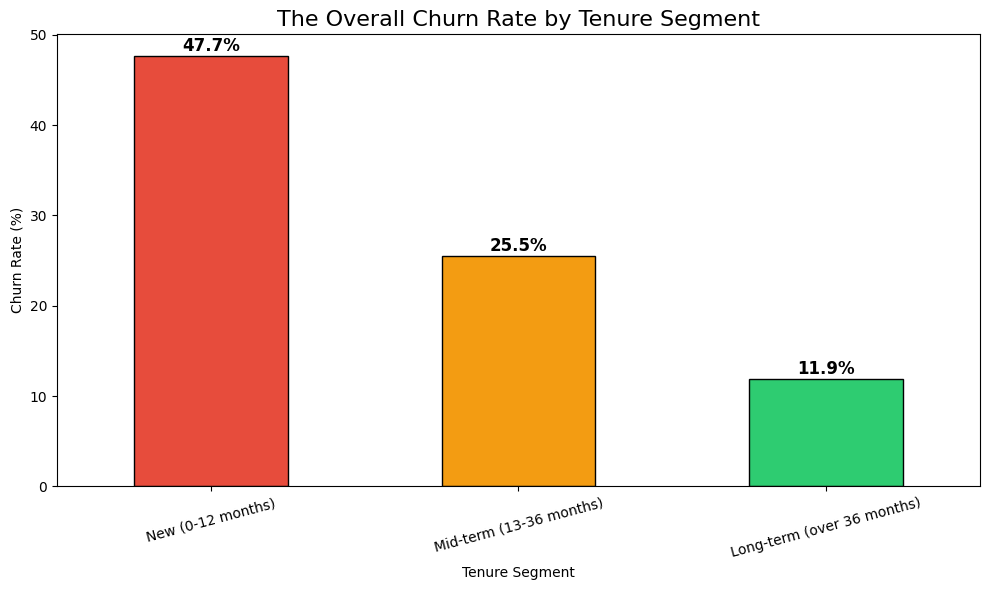

In [8]:
tenure_churn = df.groupby('Tenure_Segment')['Churn'].mean()*100

print("Churn Rate by Tenure Segment:")
print(tenure_churn.round(1))

plt.figure(figsize = (10, 6))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
tenure_churn.plot(kind = 'bar', color = colors, edgecolor = 'black')

plt.title('The Overall Churn Rate by Tenure Segment', fontsize = 16)
plt.xlabel('Tenure Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation = 15)

for i, value in enumerate(tenure_churn):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha = 'center', fontsize = 12,
            fontweight = 'bold')

plt.tight_layout()
plt.show()

Customers per Charge Segment:
Charge_Segment
High (over $65)    3899
Low ($0-$35)       1735
Mid ($35-$65)      1409
Name: count, dtype: int64

Churn Rate by Charge Segment:
Charge_Segment
Low ($0-$35)       10.9
Mid ($35-$65)      23.1
High (over $65)    34.7
Name: Churn, dtype: float64


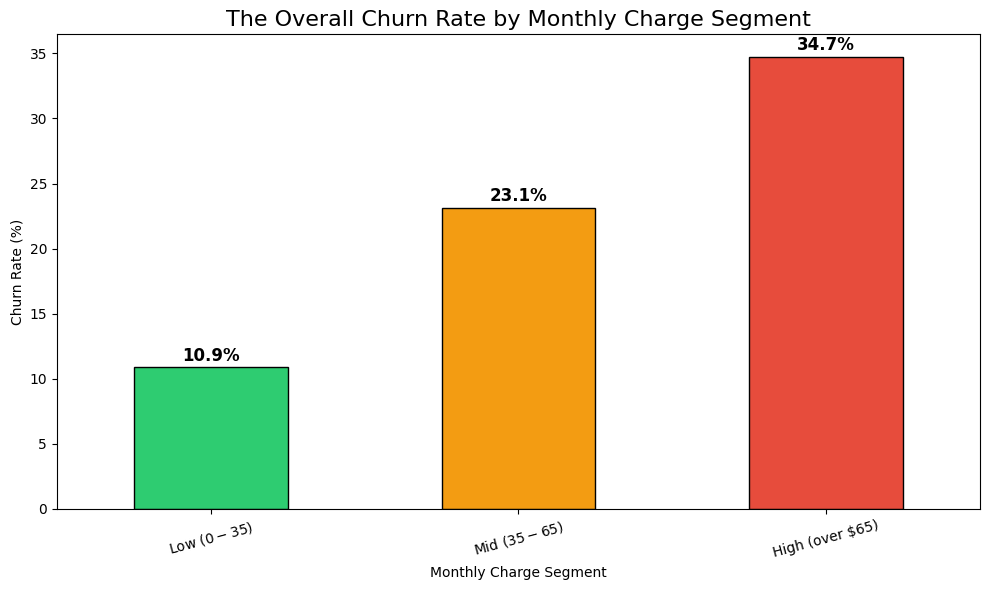

In [10]:
df['Charge_Segment'] = pd.cut(df['MonthlyCharges'], bins=[0, 35, 65, 120],
                               labels = ['Low ($0-$35)', 
                                      'Mid ($35-$65)', 
                                      'High (over $65)'])

charge_churn = df.groupby('Charge_Segment')['Churn'].mean()*100

print("Customers per Charge Segment:")
print(df['Charge_Segment'].value_counts())
print("\nChurn Rate by Charge Segment:")
print(charge_churn.round(1))

plt.figure(figsize = (10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
charge_churn.plot(kind = 'bar', color = colors, edgecolor = 'black')

plt.title('The Overall Churn Rate by Monthly Charge Segment', fontsize = 16)
plt.xlabel('Monthly Charge Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation = 15)

for i, value in enumerate(charge_churn):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha = 'center', fontsize = 12,
             fontweight = 'bold')

plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches = 'tight', dpi = 150)
plt.show()

In [11]:
segment_churn = df.groupby(['Tenure_Segment', 'Charge_Segment'])['Churn'].mean()*100

print("Churn Rate bt Tenure & Charge Segment:")
print(segment_churn.round(1))

Churn Rate bt Tenure & Charge Segment:
Tenure_Segment              Charge_Segment 
New (0-12 months)           Low ($0-$35)       23.9
                            Mid ($35-$65)      40.8
                            High (over $65)    66.5
Mid-term (13-36 months)     Low ($0-$35)        5.2
                            Mid ($35-$65)      15.7
                            High (over $65)    39.0
Long-term (over 36 months)  Low ($0-$35)        2.1
                            Mid ($35-$65)       9.1
                            High (over $65)    15.9
Name: Churn, dtype: float64


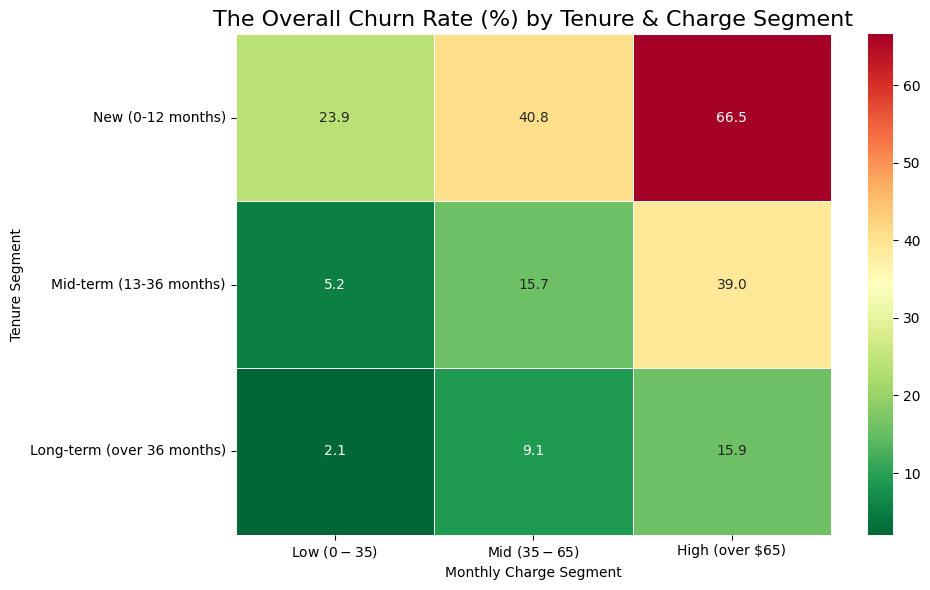

In [13]:
segment_pivot = df.pivot_table(index = 'Tenure_Segment', columns = 'Charge_Segment',
                                values = 'Churn',
                                aggfunc = 'mean')*100

plt.figure(figsize = (10, 6))
sns.heatmap(segment_pivot, annot = True, fmt = '.1f', cmap = 'RdYlGn_r',
            linewidths = 0.5)

plt.title('The Overall Churn Rate (%) by Tenure & Charge Segment', fontsize = 16)
plt.xlabel('Monthly Charge Segment')
plt.ylabel('Tenure Segment')
plt.tight_layout()
plt.show()

In [18]:
contract_churn = df.groupby(['Contract_One year', 
                             'Contract_Two year'])['Churn'].mean() * 100

contract_df = pd.DataFrame({
    'Contract Type': ['Month-to-month', 'Two year', 'One year'],
    'Churn Rate': [contract_churn[0,0], contract_churn[0,1], contract_churn[1,0]]
})

plt.figure(figsize = (10, 6))
colors = ['#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(contract_df['Contract Type'], contract_df['Churn Rate'],
               color = colors, 
               edgecolor = 'black')

plt.title('Churn Rate by Contract Type', fontsize = 16)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, contract_df['Churn Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.5, f'{value:.1f}%',
             ha = 'center', 
             fontsize = 12, 
             fontweight = 'bold')

plt.tight_layout()
plt.show()

print("\nContract Type Segments:")
print(contract_df.to_string(index = False))

KeyError: (0, 0)

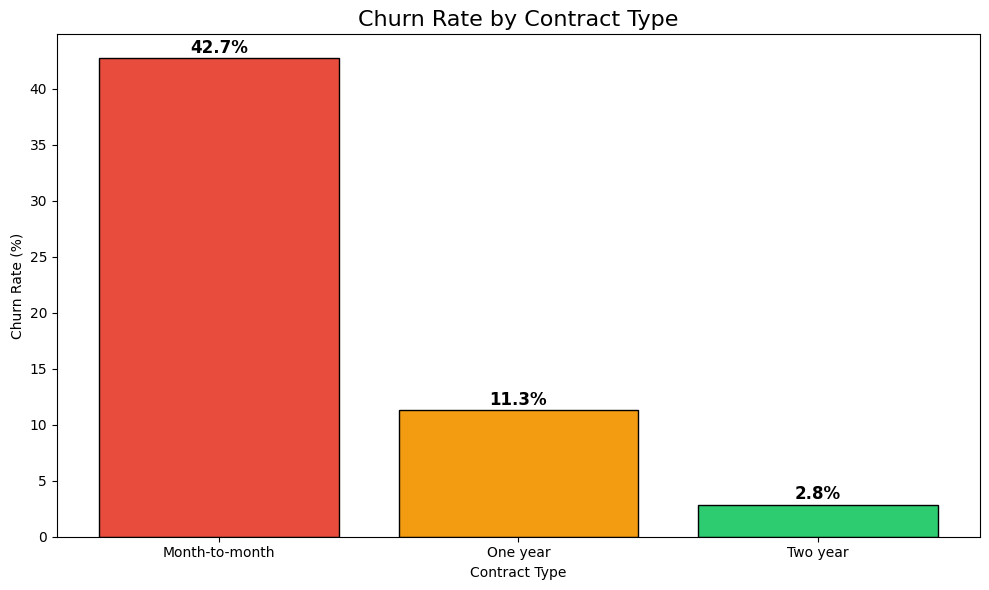


Contract Type Segments:
 Contract Type  Churn Rate
Month-to-month   42.709677
      One year   11.269518
      Two year    2.831858


In [17]:
month_to_month = df[(df['Contract_One year'] == False) & 
                    (df['Contract_Two year'] == False)]['Churn'].mean() * 100

one_year = df[df['Contract_One year'] == True]['Churn'].mean() * 100

two_year = df[df['Contract_Two year']==True]['Churn'].mean() * 100

contract_df = pd.DataFrame({
    'Contract Type': ['Month-to-month', 'One year', 'Two year'],
    'Churn Rate': [month_to_month, one_year, two_year]
})

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = plt.bar(contract_df['Contract Type'], contract_df['Churn Rate'],
               color = colors,
               edgecolor = 'black')

plt.title('Churn Rate by Contract Type', fontsize = 16)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, contract_df['Churn Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.5, f'{value:.1f}%',
             ha = 'center',
             fontsize = 12,
             fontweight = 'bold')

plt.tight_layout()
plt.show()

print("\nContract Type Segments:")
print(contract_df.to_string(index = False))